In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

path = "../dataset/Sales - Marketing customer dataset.csv"
data = pd.read_csv(path)

data.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


# Soal Ketiga : Modeling Dengan Preprocessing

## Duplikat

In [2]:
duplicate_count = data.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0


## Missing value

In [3]:
# Missing values (%)
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

print(missing_data)

                            Missing Count  Missing %
coupon_code                          6133  40.886667
age                                  1200   8.000000
total_spent                          1050   7.000000
gender                                738   4.920000
satisfaction_score                    702   4.680000
customer_id                             0   0.000000
last_3_month_purchase_freq              0   0.000000
lifetime_value                          0   0.000000
marketing_spend_per_user                0   0.000000
nps_score                               0   0.000000
payment_method                          0   0.000000
delivery_delay_days                     0   0.000000
refund_requested                        0   0.000000
support_tickets                         0   0.000000
discount_used                           0   0.000000
avg_order_value                         0   0.000000
email_click_rate                        0   0.000000
email_open_rate                         0   0.

In [2]:
data['coupon_code'] = data['coupon_code'].fillna('No_Coupon')
data.dropna(subset=['gender'], inplace=True)

median_satisfaction_score = data['satisfaction_score'].median()
data['satisfaction_score'] = data['satisfaction_score'].fillna(median_satisfaction_score)

mean_age = data['age'].mean()
data['age'] = data['age'].fillna(mean_age)

median_total_spent = data['total_spent'].median()
data['total_spent'] = data['total_spent'].fillna(median_total_spent)

In [3]:
# Missing values (%)
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100

missing_data = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values(by='Missing %', ascending=False)

print(missing_data)

                            Missing Count  Missing %
customer_id                             0        0.0
gender                                  0        0.0
last_3_month_purchase_freq              0        0.0
lifetime_value                          0        0.0
marketing_spend_per_user                0        0.0
nps_score                               0        0.0
satisfaction_score                      0        0.0
payment_method                          0        0.0
delivery_delay_days                     0        0.0
refund_requested                        0        0.0
support_tickets                         0        0.0
coupon_code                             0        0.0
discount_used                           0        0.0
avg_order_value                         0        0.0
total_spent                             0        0.0
email_click_rate                        0        0.0
email_open_rate                         0        0.0
pages_per_session                       0     

## Outlier

Berdasarkan EDA

*   Fitur Kategori sudah bersih kecuali fitur tanggal yang perlu melakukan penanganan
*   Fitur ordinal juga sudah konsisten 1-5 dan 0-10
*   Fitur numerik juga sudah tidak ada anomali
*   Fitur target juga hanya 2 nilai unik
Jdi kita bisa langsung menengecek di fitur numerik kecuali id






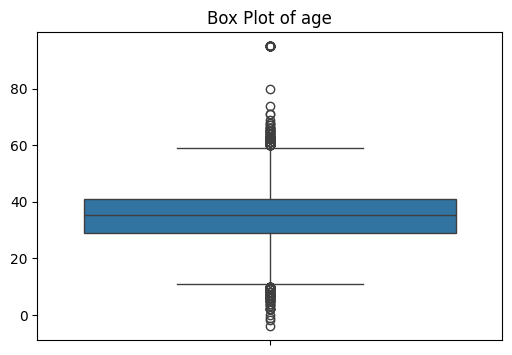

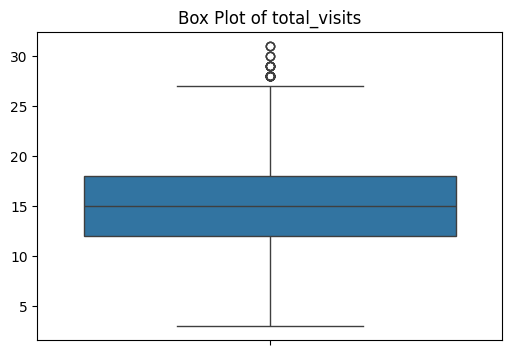

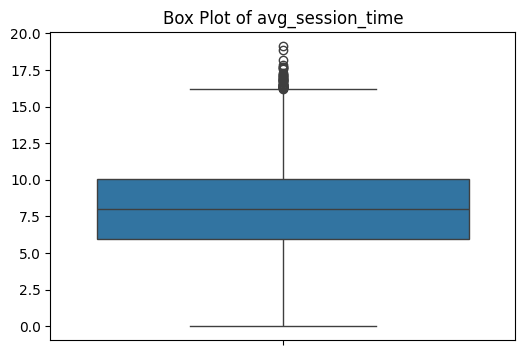

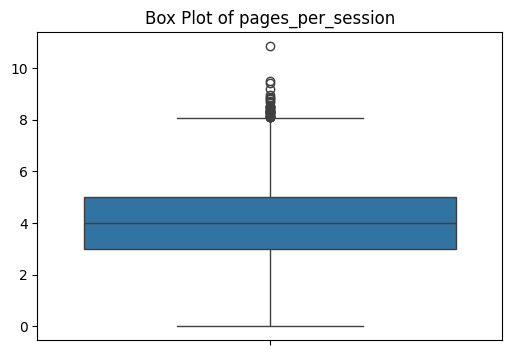

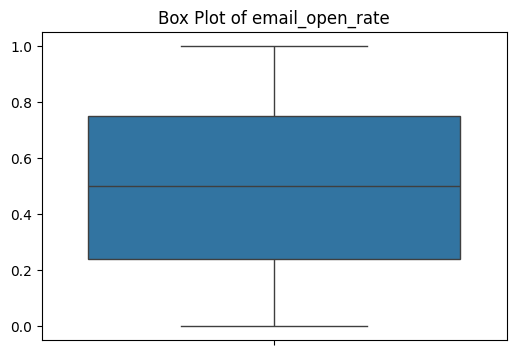

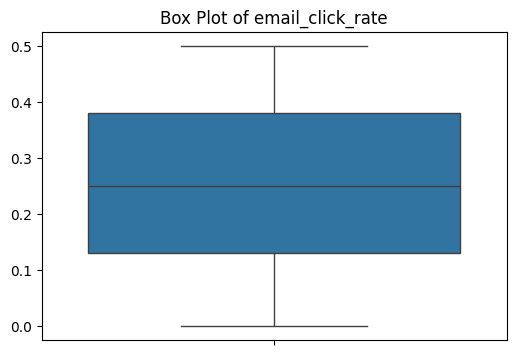

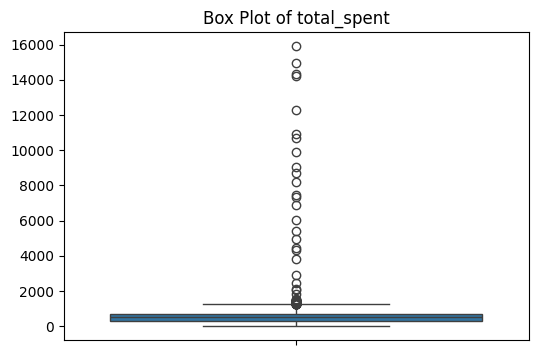

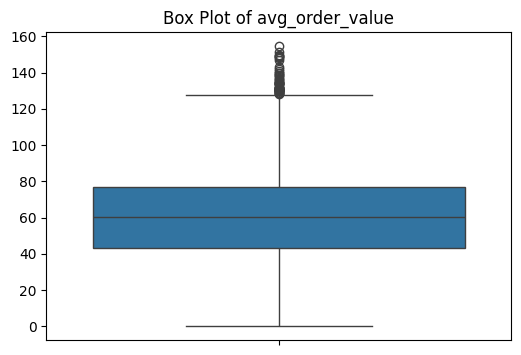

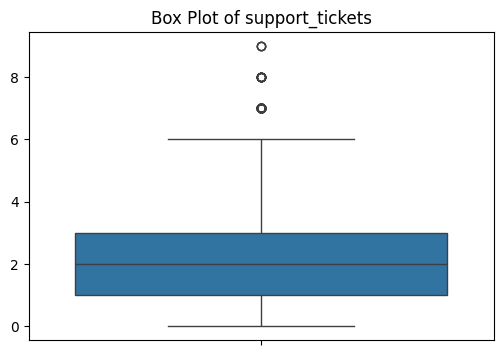

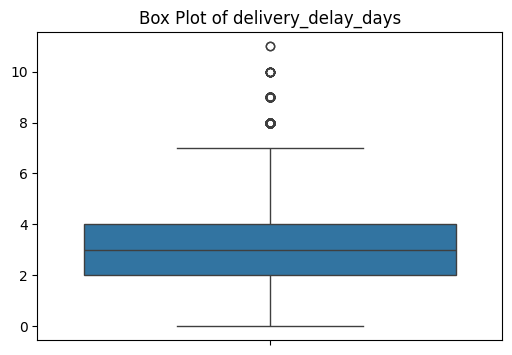

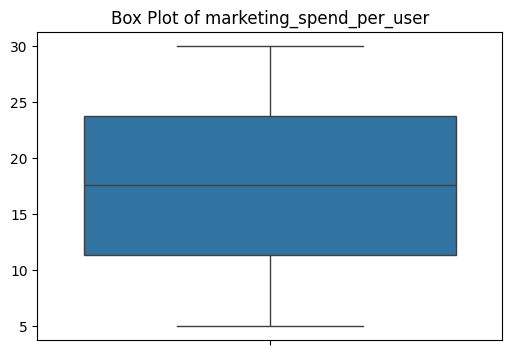

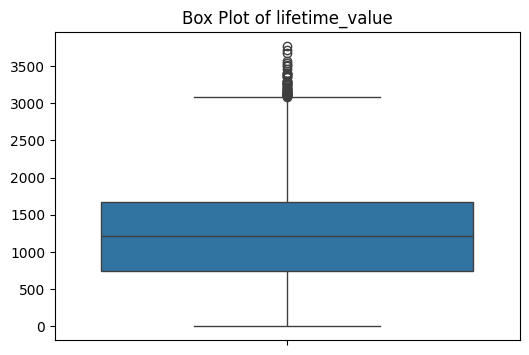

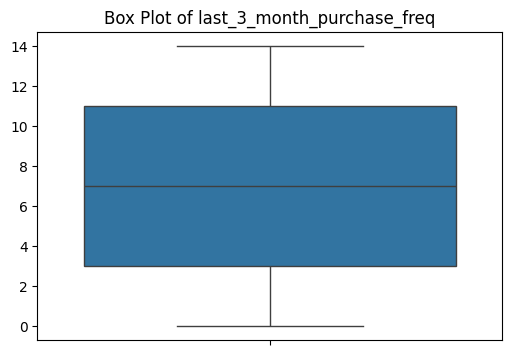

In [4]:
numerical_features = [
    'age',
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'email_open_rate',
    'email_click_rate',
    'total_spent',
    'avg_order_value',
    'support_tickets',
    'delivery_delay_days',
    'marketing_spend_per_user',
    'lifetime_value',
    'last_3_month_purchase_freq'
]

for col in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
    plt.show()

In [5]:
data[numerical_features].describe()

,age,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,support_tickets,delivery_delay_days,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq
count,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000,14262.000000
mean,35.179186,14.997546,8.022206,4.001681,0.497153,0.251217,522.494557,60.033333,1.993409,2.983032,17.574045,1234.788757,6.973145
std,9.900666,3.891352,2.990511,1.483149,0.290195,0.144581,439.440162,24.737194,1.418110,1.724563,7.184751,656.815291,4.331479
min,-4.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,5.000000,0.368886,0.000000
25%,29.000000,12.000000,5.976742,2.981162,0.240000,0.130000,317.250743,42.966632,1.000000,2.000000,11.360000,740.036076,3.000000
50%,35.179186,15.000000,7.998571,3.993820,0.500000,0.250000,499.781618,60.093209,2.000000,3.000000,17.630000,1215.667843,7.000000
75%,41.000000,18.000000,10.059839,5.014078,0.750000,0.380000,684.083832,76.834300,3.000000,4.000000,23.770000,1676.826927,11.000000
max,95.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,9.000000,11.000000,30.000000,3767.490455,14.000000


In [6]:
print("### Outlier Analysis ###\n")

for col in numerical_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_percentage = (outlier_count / len(data)) * 100

    print(f"Feature: {col}")
    print(f"  Number of outliers: {outlier_count}")
    print(f"  Percentage of outliers: {outlier_percentage:.2f}%\n")

### Outlier Analysis ###

Feature: age
  Number of outliers: 205
  Percentage of outliers: 1.44%

Feature: total_visits
  Number of outliers: 38
  Percentage of outliers: 0.27%

Feature: avg_session_time
  Number of outliers: 44
  Percentage of outliers: 0.31%

Feature: pages_per_session
  Number of outliers: 33
  Percentage of outliers: 0.23%

Feature: email_open_rate
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: email_click_rate
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: total_spent
  Number of outliers: 115
  Percentage of outliers: 0.81%

Feature: avg_order_value
  Number of outliers: 52
  Percentage of outliers: 0.36%

Feature: support_tickets
  Number of outliers: 74
  Percentage of outliers: 0.52%

Feature: delivery_delay_days
  Number of outliers: 177
  Percentage of outliers: 1.24%

Feature: marketing_spend_per_user
  Number of outliers: 0
  Percentage of outliers: 0.00%

Feature: lifetime_value
  Number of outliers: 51
  Percentage o

### Age

In [7]:
import numpy as np
data = data[(data['age'] >= 0) | (data['age'].isna())]

Berdasarkan analisis IQR, ditemukan beberapa outlier pada fitur numerik. Namun, tidak seluruh outlier dihapus karena sebagian besar masih mungkin merepresentasikan perilaku pelanggan yang valid. Penanganan hanya dilakukan pada nilai yang secara logis tidak mungkin, seperti usia negatif.

## Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

categorical_features_to_encode = [
    'gender', 'country', 'city', 'acquisition_channel',
    'device_type', 'subscription_type', 'coupon_code', 'payment_method'
]

le = LabelEncoder()
for col in categorical_features_to_encode:
    data[col] = le.fit_transform(data[col].astype(str))

## Feature Engineering 4 datetime

In [9]:
# FEATURE ENGINEERING UNTUK KOLOM TANGGAL
data['signup_date'] = pd.to_datetime(data['signup_date'])
data['last_purchase_date'] = pd.to_datetime(data['last_purchase_date'])

data['days_to_last_purchase'] = (data['last_purchase_date'] - data['signup_date']).dt.days

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month

data = data.drop(columns=['signup_date', 'last_purchase_date'])

print(data[['days_to_last_purchase', 'signup_year', 'signup_month']].head())

   days_to_last_purchase  signup_year  signup_month
0                    966         2022             5
2                    249         2023             8
3                   -253         2024             1
4                    261         2023             7
5                   -474         2024             5


In [10]:
data.head()

,customer_id,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,...,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,days_to_last_purchase,signup_year,signup_month
0,10001,1,52.0,2,0,0,2,0,1,7,...,4,3.0,10,27.56,915.310827,14,0,966,2022,5
2,10003,0,27.0,1,4,0,1,0,1,18,...,4,5.0,6,13.51,1379.150885,9,0,249,2023,8
3,10004,0,36.0,2,5,1,2,0,1,16,...,2,4.0,6,25.65,774.652684,7,0,-253,2024,1
4,10005,1,29.0,4,3,4,1,1,0,12,...,0,3.0,1,12.39,87.680409,11,0,261,2023,7
5,10006,1,29.0,1,5,2,1,1,0,13,...,3,3.0,10,16.30,467.452413,14,0,-474,2024,5


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14259 entries, 0 to 14999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 14259 non-null  int64  
 1   gender                      14259 non-null  int32  
 2   age                         14259 non-null  float64
 3   country                     14259 non-null  int32  
 4   city                        14259 non-null  int32  
 5   acquisition_channel         14259 non-null  int32  
 6   device_type                 14259 non-null  int32  
 7   subscription_type           14259 non-null  int32  
 8   is_premium_user             14259 non-null  int64  
 9   total_visits                14259 non-null  int64  
 10  avg_session_time            14259 non-null  float64
 11  pages_per_session           14259 non-null  float64
 12  email_open_rate             14259 non-null  float64
 13  email_click_rate            14259 no

## Drop Id

In [12]:
data = data.drop(columns=['customer_id'])

## Korelasi Matrix

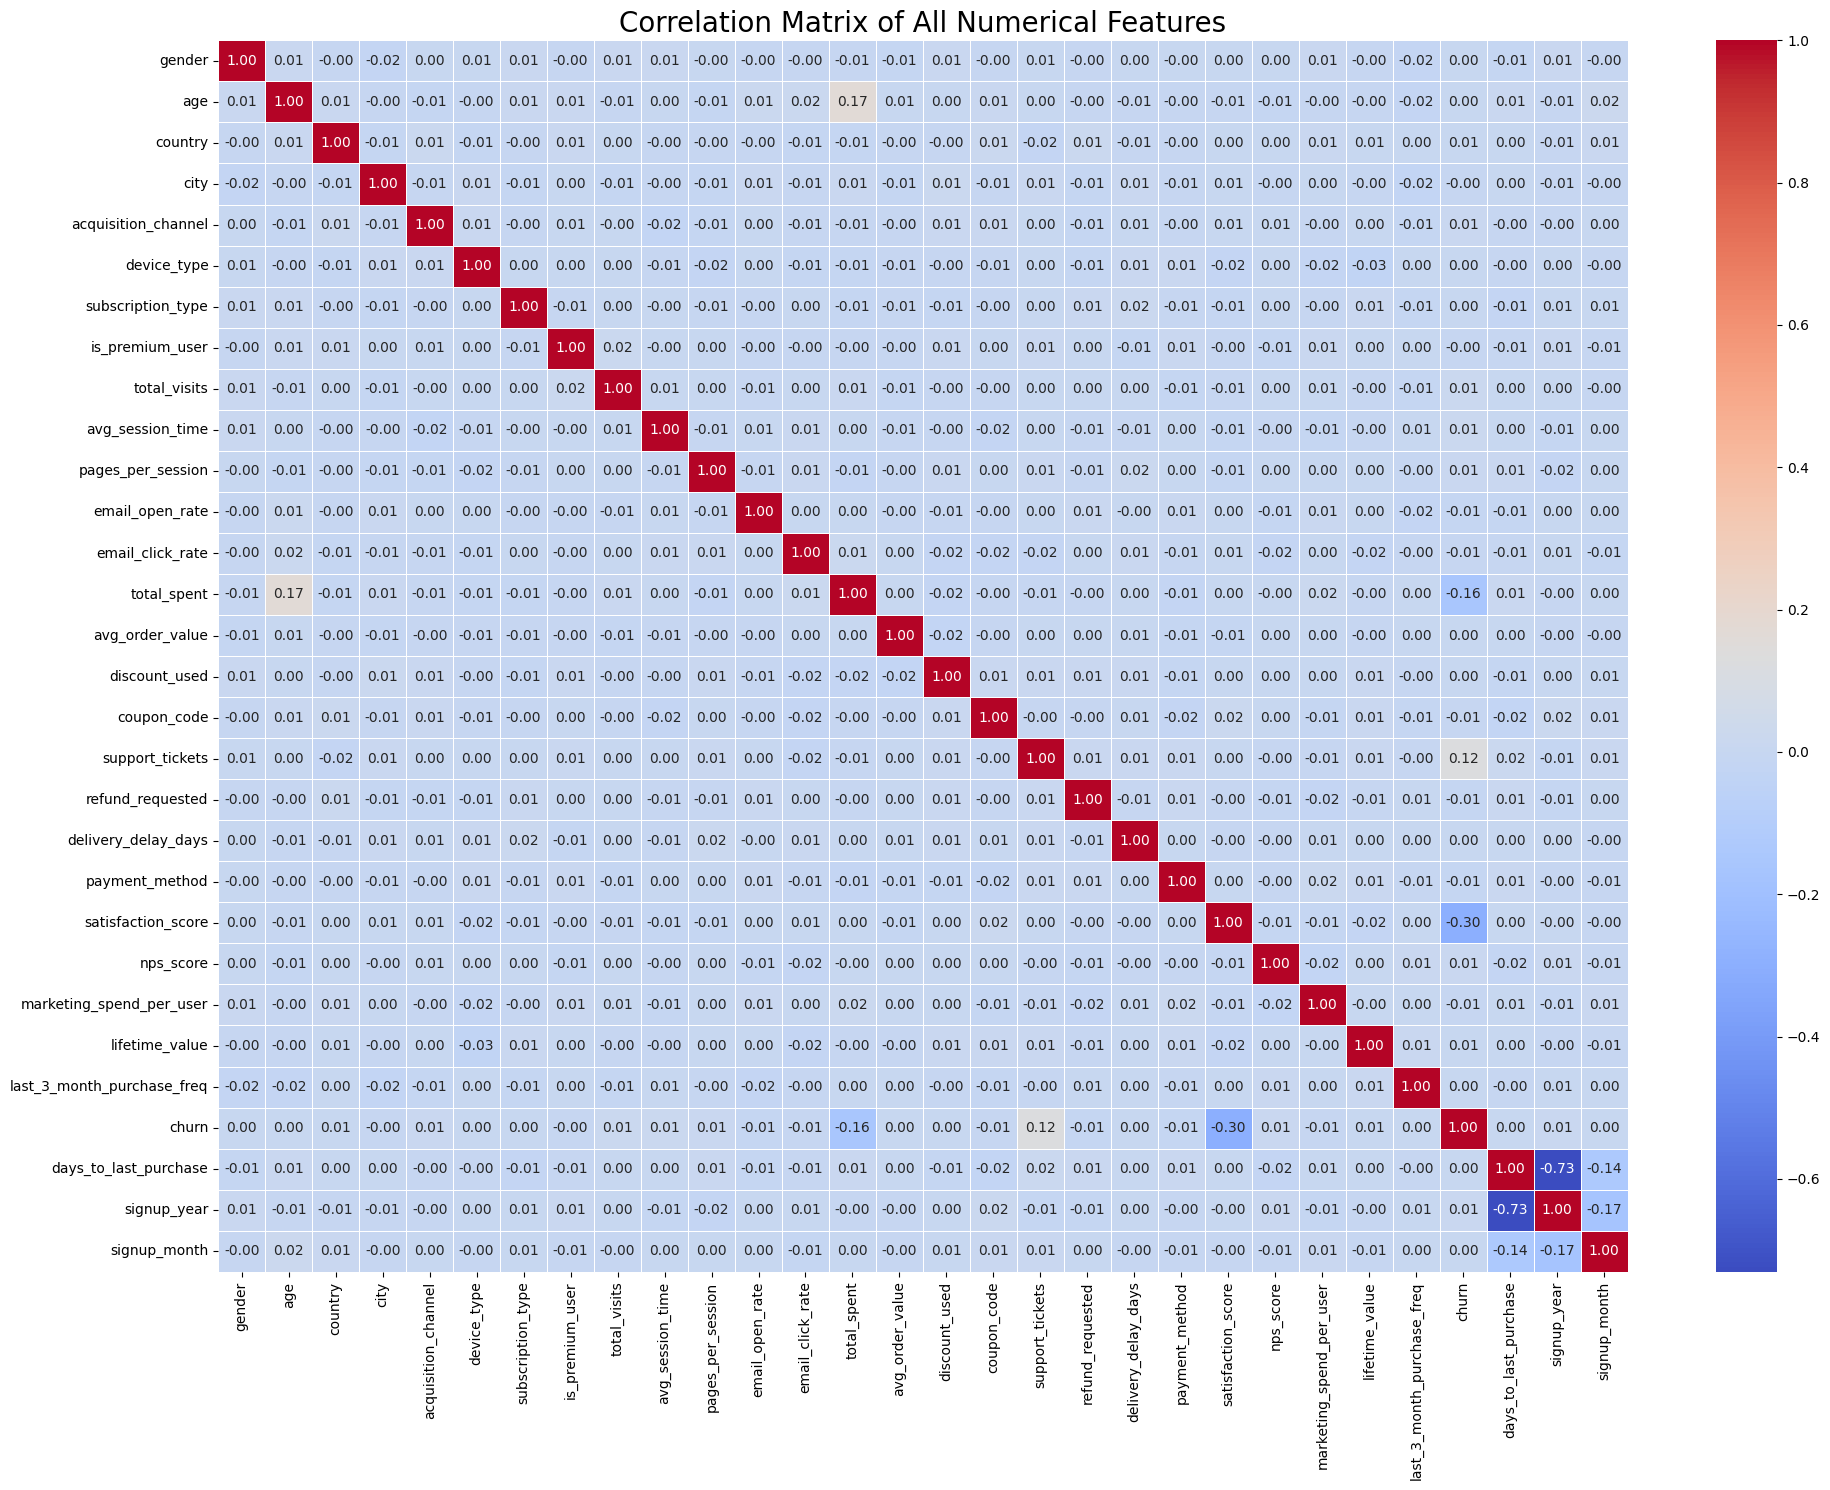

In [13]:
correlation_matrix_all = data.corr(numeric_only=True)

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Declare x,y dan Split

In [14]:
X = data.drop(columns=['churn'])
y = data['churn']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape X_train (Ori):", X_train.shape)
print("Shape X_test (Ori) :", X_test.shape)

Shape X_train (Ori): (11407, 29)
Shape X_test (Ori) : (2852, 29)


## Penanganan Imbalance

In [16]:
from imblearn.combine import SMOTETomek
from collections import Counter

print("Original class distribution in y_train:", Counter(y_train))

smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train, y_train)
print("Class distribution after SMOTE-Tomek:", Counter(y_train_resampled))

Original class distribution in y_train: Counter({0: 9681, 1: 1726})
Class distribution after SMOTE-Tomek: Counter({0: 9399, 1: 9399})


## Standarisasi

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)
y_train_final = y_train_resampled

print("Data Train Siap (X_train_scaled) Shape:", X_train_scaled.shape)
print("Data Test Siap  (X_test_scaled)  Shape:", X_test_scaled.shape)

Data Train Siap (X_train_scaled) Shape: (18798, 29)
Data Test Siap  (X_test_scaled)  Shape: (2852, 29)


StandardScaler di-fit hanya pada data training. Selanjutnya, parameter mean dan standar deviasi yang diperoleh dari data training digunakan kembali untuk mentransformasikan data test. Hal ini dilakukan agar data test berada pada ruang fitur yang sama dengan data training tanpa menyebabkan data leakage.

## Modeling

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


=== Logistic Regression Evaluation ===

-- Accuracy --
Train: 0.8209
Test : 0.7675

-- F1 Score (Macro) --
Train: 0.8209
Test : 0.6387

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      9399
           1       0.81      0.83      0.82      9399

    accuracy                           0.82     18798
   macro avg       0.82      0.82      0.82     18798
weighted avg       0.82      0.82      0.82     18798


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.91      0.81      0.85      2407
           1       0.35      0.55      0.42       445

    accuracy                           0.77      2852
   macro avg       0.63      0.68      0.64      2852
weighted avg       0.82      0.77      0.79      2852



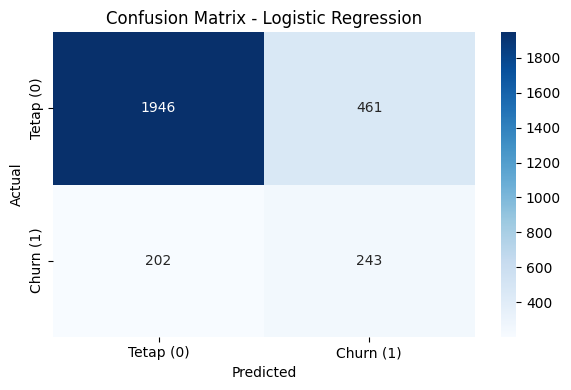

In [19]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train
lr_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("=== Logistic Regression Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_lr):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_lr):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_lr, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_lr, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_lr))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_lr))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Setelah dilakukan preprocessing dan penyeimbangan kelas pada data latih, Logistic Regression mampu menghasilkan performa yang lebih seimbang dalam mendeteksi kedua kelas. Recall pada Kelas 1 meningkat menjadi 55%, menunjukkan bahwa model semakin mampu mengenali pelanggan yang berpotensi churn.

=== Random Forest Evaluation ===

-- Accuracy --
Train: 1.0000
Test : 0.8513

-- F1 Score (Macro) --
Train: 1.0000
Test : 0.7503

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9399
           1       1.00      1.00      1.00      9399

    accuracy                           1.00     18798
   macro avg       1.00      1.00      1.00     18798
weighted avg       1.00      1.00      1.00     18798


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2407
           1       0.52      0.69      0.59       445

    accuracy                           0.85      2852
   macro avg       0.73      0.79      0.75      2852
weighted avg       0.87      0.85      0.86      2852



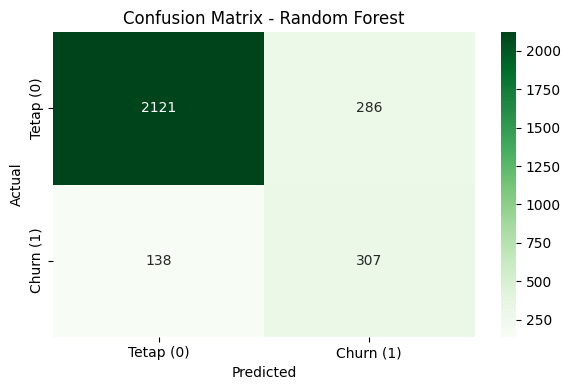

In [20]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=1000)

# Train
rf_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
print("=== Random Forest Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_rf):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_rf):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_rf, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_rf, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_rf))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_rf))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Setelah preprocessing dan penyeimbangan kelas, Random Forest menunjukkan peningkatan kemampuan mendeteksi kelas churn dengan Recall Kelas 1 mencapai 69%. Namun, perbedaan performa yang cukup besar antara data latih dan data uji mengindikasikan adanya overfitting sehingga kemampuan generalisasi model masih perlu ditingkatkan.

=== Ensemble Voting Evaluation ===

-- Accuracy --
Train: 0.9964
Test : 0.8513

-- F1 Score (Macro) --
Train: 0.9964
Test : 0.7384

-- Classification Report (Train) --
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      9399
           1       0.99      1.00      1.00      9399

    accuracy                           1.00     18798
   macro avg       1.00      1.00      1.00     18798
weighted avg       1.00      1.00      1.00     18798


-- Classification Report (Test) --
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2407
           1       0.52      0.62      0.57       445

    accuracy                           0.85      2852
   macro avg       0.72      0.76      0.74      2852
weighted avg       0.86      0.85      0.86      2852



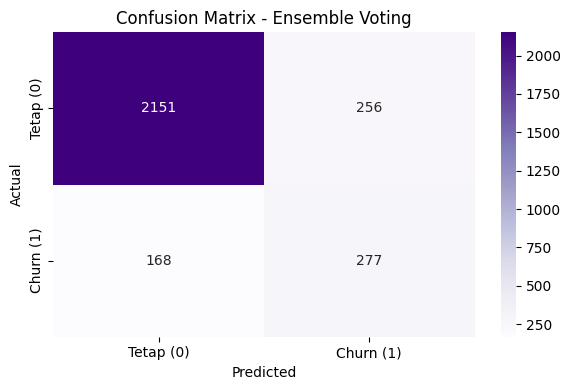

In [21]:
lr_base = LogisticRegression(random_state=42, max_iter=1000)
rf_base = RandomForestClassifier(random_state=42, n_estimators=1000)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_base),
        ('rf', rf_base),
        ('xgb', xgb_base)
    ],
    voting='soft'
)

# Train
voting_model.fit(X_train_scaled, y_train_final)

# Predict
y_train_pred_vt = voting_model.predict(X_train_scaled)
y_test_pred_vt = voting_model.predict(X_test_scaled)

# Evaluation
print("=== Ensemble Voting Evaluation ===")
print("\n-- Accuracy --")
print(f"Train: {accuracy_score(y_train_final, y_train_pred_vt):.4f}")
print(f"Test : {accuracy_score(y_test, y_test_pred_vt):.4f}")
print("\n-- F1 Score (Macro) --")
print(f"Train: {f1_score(y_train_final, y_train_pred_vt, average='macro'):.4f}")
print(f"Test : {f1_score(y_test, y_test_pred_vt, average='macro'):.4f}")

print("\n-- Classification Report (Train) --")
print(classification_report(y_train_final, y_train_pred_vt))
print("\n-- Classification Report (Test) --")
print(classification_report(y_test, y_test_pred_vt))

cm_vt = confusion_matrix(y_test, y_test_pred_vt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_vt, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
plt.title('Confusion Matrix - Ensemble Voting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Ensemble Voting menghasilkan performa pengujian yang kompetitif dengan Macro F1 sebesar 0.7384 dan Recall Kelas 1 sebesar 62%. Meskipun akurasi pengujian mencapai 85%, perbedaan performa antara data latih dan data uji masih menunjukkan indikasi overfitting sehingga model belum dapat dikategorikan sepenuhnya stabil.

In [32]:
summary_data_after = {
    'Model': ['Logistic Regression', 'Random Forest', 'Ensemble Voting'],
    'Accuracy': [0.7675, 0.8513, 0.8513],
    'F1-Score (Macro)': [0.6387, 0.7503, 0.7384],
    'Precision (Churn/1)': [0.35, 0.52, 0.52], 
    'Recall (Churn/1)': [0.55, 0.69, 0.62]
}

data_summary_after = pd.DataFrame(summary_data_after)
print(data_summary_after.to_string(index=False))

              Model  Accuracy  F1-Score (Macro)  Precision (Churn/1)  Recall (Churn/1)
Logistic Regression    0.7675            0.6387                 0.35              0.55
      Random Forest    0.8513            0.7503                 0.52              0.69
    Ensemble Voting    0.8513            0.7384                 0.52              0.62


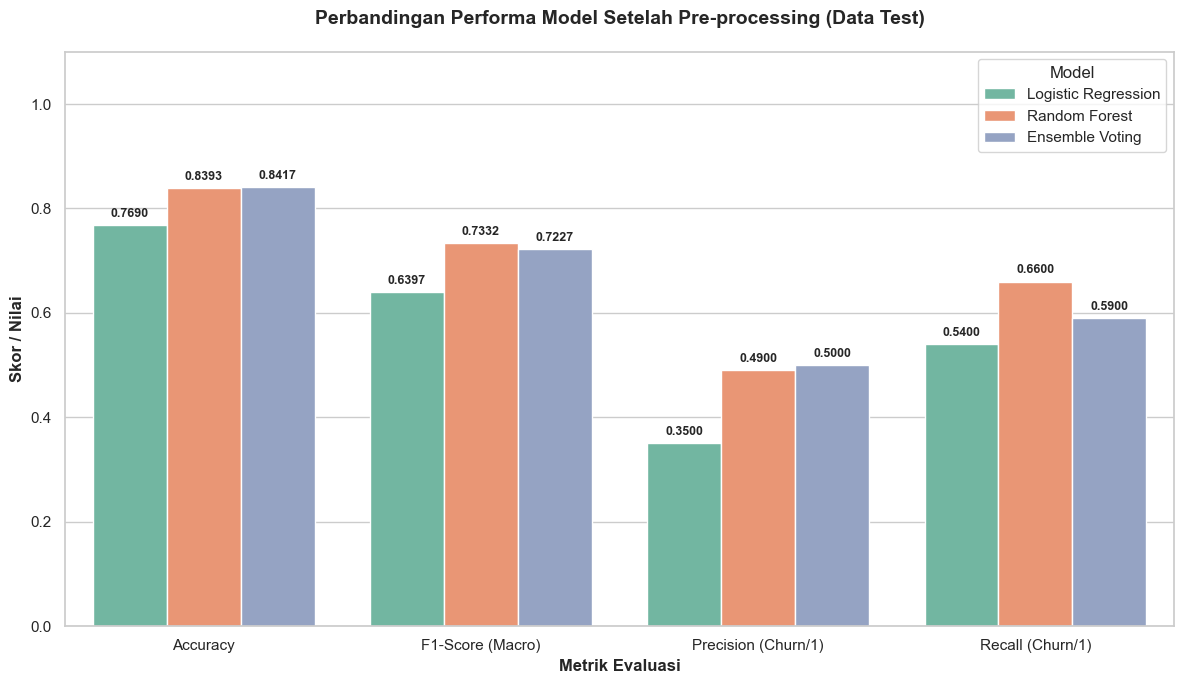

In [23]:

data_melted = pd.melt(
    data_summary_after, id_vars="Model", var_name="Metrik", value_name="Skor"
)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x="Metrik", y="Skor", hue="Model", data=data_melted, palette="Set2"
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.4f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

plt.title(
    "Perbandingan Performa Model Setelah Pre-processing (Data Test)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.ylabel("Skor / Nilai", fontsize=12, fontweight="bold")
plt.xlabel("Metrik Evaluasi", fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)  
plt.legend(title="Model", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

Setelah seluruh tahapan preprocessing dan penyeimbangan kelas diterapkan pada data latih, model menunjukkan peningkatan kemampuan dalam mendeteksi kelas minoritas. Nilai Macro F1 dan Recall Kelas 1 meningkat dibandingkan kondisi sebelumnya, mengindikasikan bahwa model tidak lagi terlalu bias terhadap kelas mayoritas.

Berdasarkan hasil pengujian skenario After Pre-processing, intervensi penyeimbangan kelas pada data latihan berhasil membongkar ilusi akurasi yang sebelumnya mendominasi. Meskipun tingkat akurasi pengujian (Test Accuracy) berada di kisaran 76% – 85% karena model tidak lagi menebak kelas mayoritas secara bias, kemampuan ketiga model dalam mendeteksi kelas target (1 / Churn) justru melonjak drastis. Perubahan paling radikal terjadi pada model Random Forest yang kini keluar sebagai model terbaik dalam menangkap sinyal churn dengan capaian nilai Recall test tertinggi sebesar 0.6900 dan F1-Score Macro 0.7503, walaupun model ini masih menunjukkan indikasi overfitting yang kuat karena performa data latihan yang tetap sempurna (1.0000).

Di sisi lain, model Logistic Regression berhasil terbebas dari masalah gagal konvergensi (convergence warning) berkat proses scaling data, menghasilkan peningkatan sensitivitas Recall test yang signifikan menjadi 0.5500 meskipun harus menerima akurasi globalnya berada di angka 0.7675. Sementara itu, Ensemble Voting menunjukkan performa yang sangat solid dan seimbang dengan mencatat akurasi tertinggi sebesar 0.8513 (setara dengan Random Forest), nilai Precision target yang bersaing di angka 0.5200, serta tingkat pengenalan churn (Recall) yang kuat di angka 0.6200, menjadikannya model yang paling konsisten dan minim risiko salah tebak untuk data baru.

# Soal Ke-empat : Hyperparameter Tuning dan Feature Selection

## Feature Important

Feature Importances from Logistic Regression:
                       Feature  Importance
13                 total_spent    1.550779
21          satisfaction_score    1.202147
27                 signup_year    0.559482
26       days_to_last_purchase    0.455249
0                       gender    0.380834
17             support_tickets    0.370642
15               discount_used    0.368082
7              is_premium_user    0.344534
6            subscription_type    0.336022
5                  device_type    0.303676
16                 coupon_code    0.293955
18            refund_requested    0.293846
20              payment_method    0.285732
28                signup_month    0.230096
2                      country    0.227498
19         delivery_delay_days    0.206584
3                         city    0.162159
25  last_3_month_purchase_freq    0.127885
22                   nps_score    0.118732
4          acquisition_channel    0.107545
8                 total_visits    0.051441
10      

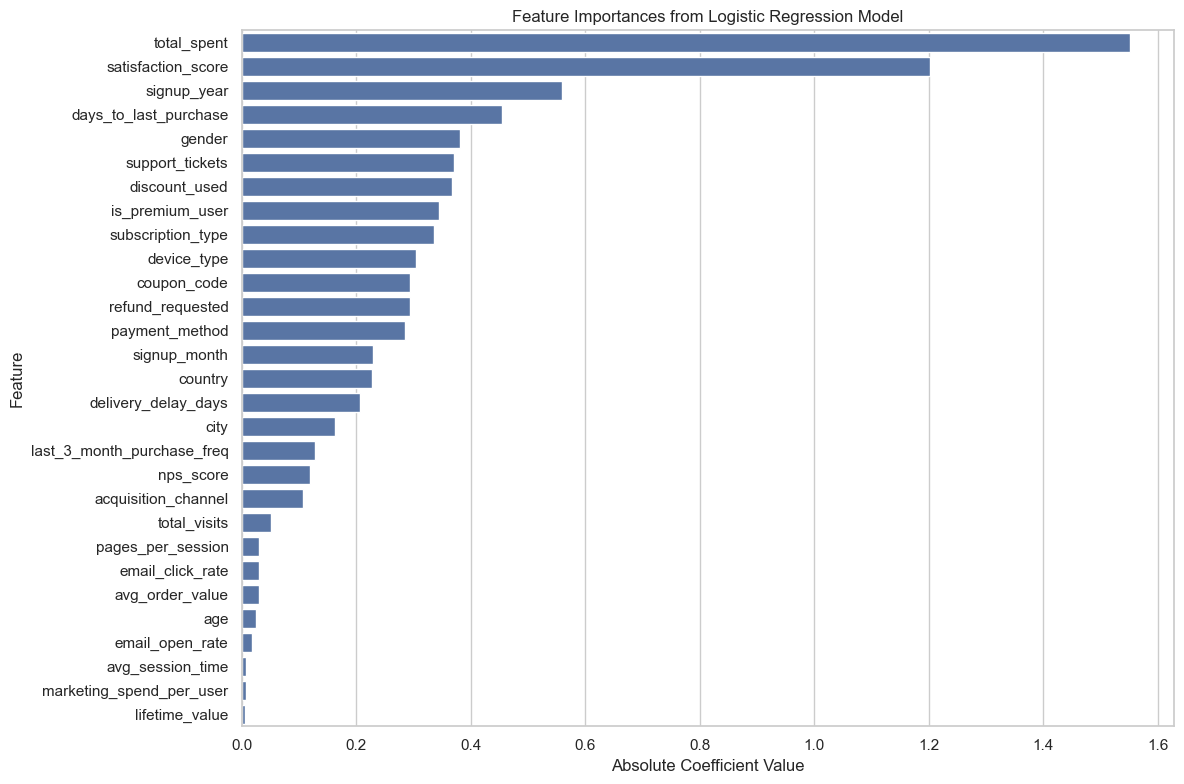

In [24]:
logistic_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': abs(lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("Feature Importances from Logistic Regression:")
print(logistic_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=logistic_importances)
plt.title('Feature Importances from Logistic Regression Model')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Importances from Random Forest:
                       Feature  Importance
21          satisfaction_score    0.267994
13                 total_spent    0.228223
17             support_tickets    0.049411
23    marketing_spend_per_user    0.022830
20              payment_method    0.022279
24              lifetime_value    0.022230
11             email_open_rate    0.021384
5                  device_type    0.021376
15               discount_used    0.021052
12            email_click_rate    0.020788
9             avg_session_time    0.020554
26       days_to_last_purchase    0.020236
14             avg_order_value    0.020068
10           pages_per_session    0.019604
1                          age    0.018989
7              is_premium_user    0.018735
2                      country    0.017522
0                       gender    0.017342
3                         city    0.017167
16                 coupon_code    0.017079
25  last_3_month_purchase_freq    0.016507
4          acq

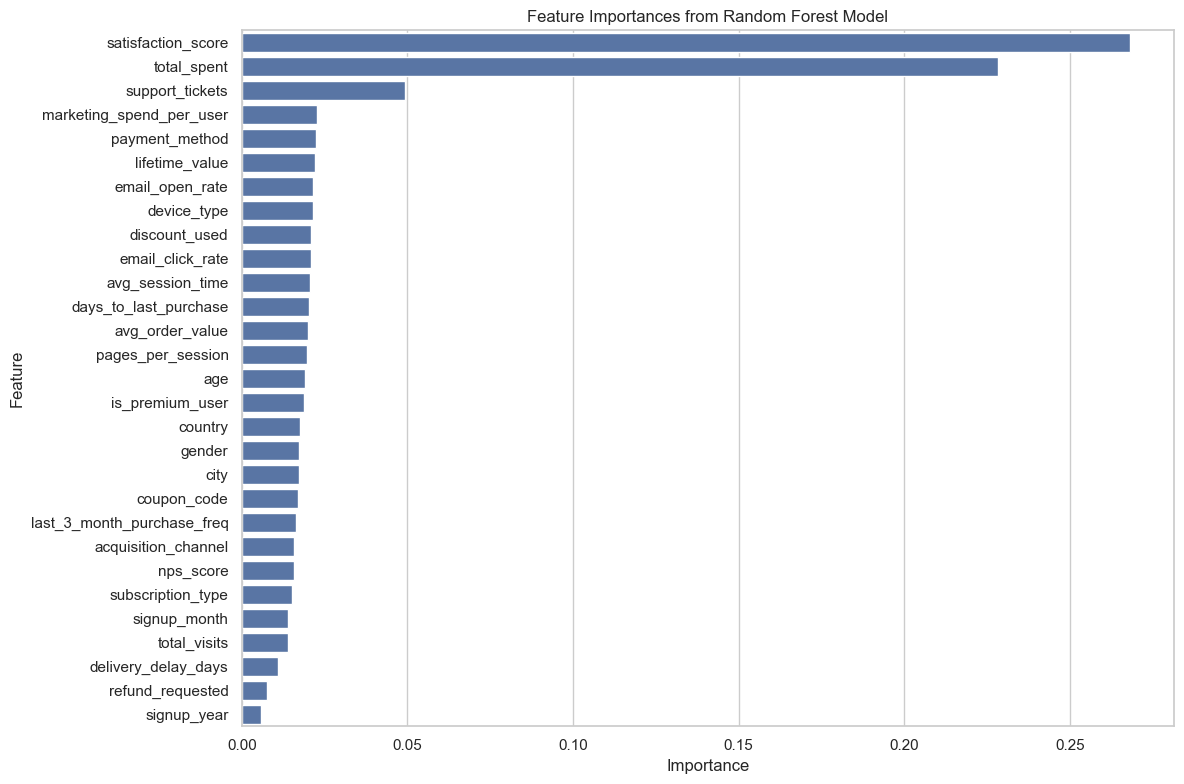

In [25]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

rf_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importances = rf_importances.sort_values(by='Importance', ascending=False)

print("Feature Importances from Random Forest:")
print(rf_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importances)
plt.title('Feature Importances from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Feature Importances from Ensemble Voting Model (Averaged Normalized):
                       Feature  Importance
21          satisfaction_score    0.226047
13                 total_spent    0.199726
17             support_tickets    0.072662
7              is_premium_user    0.036563
15               discount_used    0.032153
6            subscription_type    0.030217
0                       gender    0.029537
27                 signup_year    0.028875
26       days_to_last_purchase    0.028740
18            refund_requested    0.028431
5                  device_type    0.027900
20              payment_method    0.024871
16                 coupon_code    0.024305
2                      country    0.019858
28                signup_month    0.017271
3                         city    0.016269
25  last_3_month_purchase_freq    0.014895
19         delivery_delay_days    0.014862
4          acquisition_channel    0.014167
22                   nps_score    0.013805
12            email_click_r

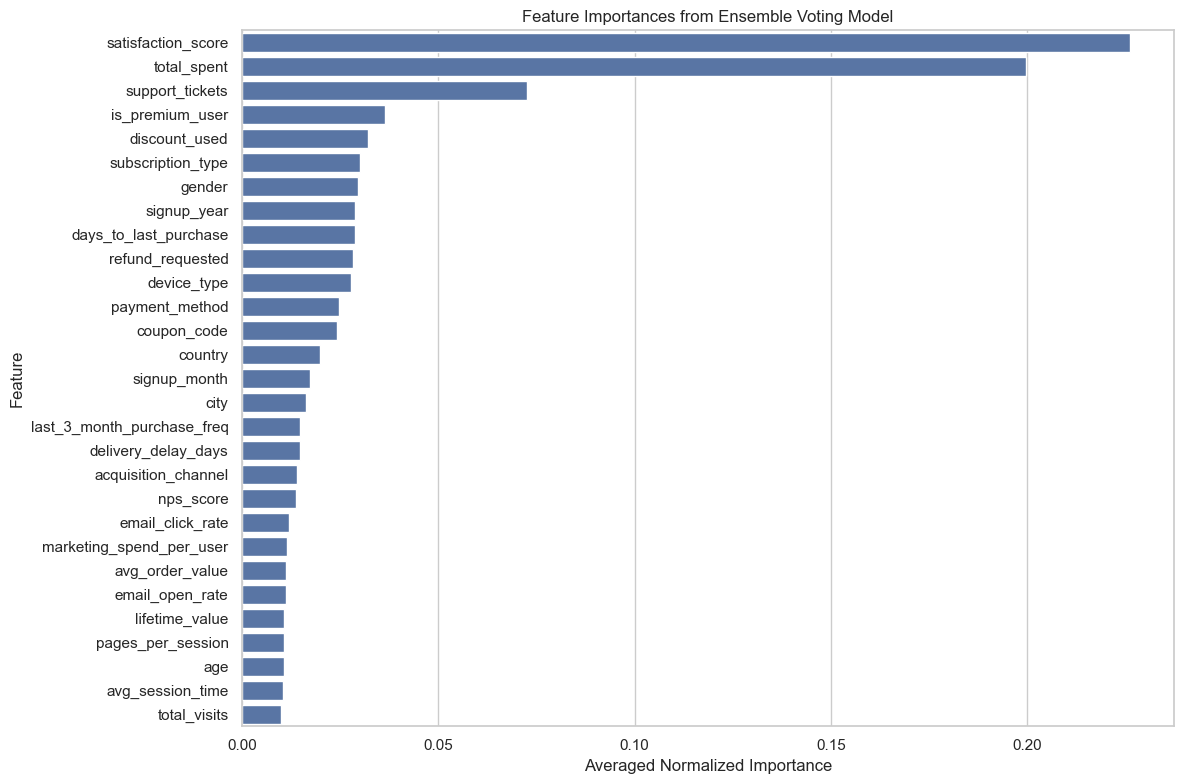

In [26]:
feature_names = X_train.columns

lr_importances_raw = abs(voting_model.estimators_[0].coef_[0])
rf_importances_raw = voting_model.estimators_[1].feature_importances_
xgb_importances_raw = voting_model.estimators_[2].feature_importances_

lr_importances_norm = lr_importances_raw / lr_importances_raw.sum()
rf_importances_norm = rf_importances_raw / rf_importances_raw.sum()
xgb_importances_norm = xgb_importances_raw / xgb_importances_raw.sum()

df_lr_imp = pd.DataFrame({'Feature': feature_names, 'Importance': lr_importances_norm})
df_rf_imp = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances_norm})
df_xgb_imp = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importances_norm})

combined_importances = df_rf_imp.set_index('Feature')
combined_importances['Importance'] += df_lr_imp.set_index('Feature')['Importance']
combined_importances['Importance'] += df_xgb_imp.set_index('Feature')['Importance']

combined_importances['Importance'] /= 3 
combined_importances = combined_importances.reset_index().sort_values(by='Importance', ascending=False)

print("Feature Importances from Ensemble Voting Model (Averaged Normalized):")
print(combined_importances)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=combined_importances)
plt.title('Feature Importances from Ensemble Voting Model')
plt.xlabel('Averaged Normalized Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [27]:
!pip install optuna
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
def objective_lr(trial):

    params = {
        'C': trial.suggest_float('C', 1e-4, 100, log=True),
        'solver': trial.suggest_categorical(
            'solver',
            ['lbfgs', 'newton-cg', 'saga']
        )
    }

    model = LogisticRegression(
        **params,
        max_iter=2000,
        random_state=42
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train_final,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=50)

print("Best F1 Macro:", study_lr.best_value)
print("Best Parameters:", study_lr.best_params)

lr_model = LogisticRegression(
    **study_lr.best_params,
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train_final)

[I 2026-06-23 20:38:37,903] A new study created in memory with name: no-name-a67c24c4-06db-4877-920d-224862568c67
[I 2026-06-23 20:38:40,252] Trial 0 finished with value: 0.8193459055051481 and parameters: {'C': 3.6935035756125147, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.8193459055051481.
[I 2026-06-23 20:38:42,005] Trial 1 finished with value: 0.8198745356226051 and parameters: {'C': 0.02739381717865095, 'solver': 'saga'}. Best is trial 1 with value: 0.8198745356226051.
[I 2026-06-23 20:38:44,314] Trial 2 finished with value: 0.8196098757713971 and parameters: {'C': 0.11089497878281719, 'solver': 'saga'}. Best is trial 1 with value: 0.8198745356226051.
[I 2026-06-23 20:38:46,240] Trial 3 finished with value: 0.8194410290835528 and parameters: {'C': 0.005783061173539943, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.8198745356226051.
[I 2026-06-23 20:38:47,672] Trial 4 finished with value: 0.8192926268366991 and parameters: {'C': 14.579752030023473, 'solver': 'saga'}. Bes

Best F1 Macro: 0.8208296691118573
Best Parameters: {'C': 0.010833358509084937, 'solver': 'newton-cg'}


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.010833358509084937
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'newton-cg'
,max_iter,2000
,multi_class,'deprecated'


Berdasarkan hasil hyperparameter tuning menggunakan Optuna selama 50 trials, model Logistic Regression berhasil mencapai performa optimal dengan nilai F1 Macro sebesar 0.8208 pada proses cross-validation. Kombinasi parameter terbaik yang ditemukan adalah nilai regularisasi C sebesar 0.0108 dan solver newton-cg (ditemukan pada Trial 21). Nilai C yang cenderung kecil (mendekati 0) ini menandakan kekuatan regularisasi yang cukup ketat (strong regularization), yang sangat efektif dalam mengontrol kompleksitas koefisien model guna mencegah overfitting sekaligus mempertahankan kemampuan generalisasi yang optimal.

In [29]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            1000
        ),
        'max_depth': trial.suggest_int(
            'max_depth',
            4,
            10
        ),
        'min_samples_split': trial.suggest_int(
            'min_samples_split',
            5,
            25
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            4,
            15
        ),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2']
        )
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train_final,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)

print("Best F1 Macro:", study_rf.best_value)
print("Best Parameters:", study_rf.best_params)

rf_model = RandomForestClassifier(
    **study_rf.best_params,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_final)

[I 2026-06-23 20:38:56,444] A new study created in memory with name: no-name-ecaa9637-774d-4afc-8282-bd0f1eb98cae
[I 2026-06-23 20:38:59,240] Trial 0 finished with value: 0.8802184129841185 and parameters: {'n_estimators': 469, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 0 with value: 0.8802184129841185.
[I 2026-06-23 20:39:04,137] Trial 1 finished with value: 0.8812105336026936 and parameters: {'n_estimators': 752, 'max_depth': 4, 'min_samples_split': 24, 'min_samples_leaf': 12, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8812105336026936.
[I 2026-06-23 20:39:12,754] Trial 2 finished with value: 0.891278148968887 and parameters: {'n_estimators': 936, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 13, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.891278148968887.
[I 2026-06-23 20:39:18,553] Trial 3 finished with value: 0.8978766522378958 and parameters: {'n_estimators': 499, 'max_depth': 9, 'm

Best F1 Macro: 0.9039990011018538
Best Parameters: {'n_estimators': 411, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt'}


,n_estimators,411
,criterion,'gini'
,max_depth,10
,min_samples_split,7
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Berdasarkan hasil hyperparameter tuning menggunakan Optuna selama 50 trials untuk model Random Forest Classifier, diperoleh nilai F1 Macro rata-rata optimal sebesar 0.9040 pada proses cross-validation. Kombinasi hyperparameter terbaik yang ditemukan (pada Trial 27) meliputi n_estimators sebanyak 411, max_depth sebesar 10, min_samples_split sebesar 7, min_samples_leaf sebesar 4, serta opsi max_features menggunakan sqrt. Penerapan batasan max_depth pada nilai 10 dan pengaturan syarat minimum sampel per daun (min_samples_leaf sebesar 4) secara efektif membatasi pertumbuhan kompleksitas pohon keputusan secara berlebihan. Hal ini memberikan kekuatan regularisasi yang seimbang bagi model untuk mereduksi risiko overfitting ekstrem yang sebelumnya mendominasi, sekaligus menjaga performa generalisasinya tetap tinggi.

In [30]:
def objective_voting(trial):
    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 100, 500),
        'max_depth': trial.suggest_int('rf_max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 15),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('xgb_gamma', 0, 5),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'n_jobs': -1
    }

    model_lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
    model_rf = RandomForestClassifier(**rf_params)
    model_xgb = XGBClassifier(**xgb_params)

    voting_model = VotingClassifier(
        estimators=[
            ('lr', model_lr),
            ('rf', model_rf),
            ('xgb', model_xgb)
        ],
        voting='soft', 
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    score = cross_val_score(
        voting_model,
        X_train_scaled,
        y_train_final,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    ).mean()

    return score


study_voting = optuna.create_study(direction='maximize')
study_voting.optimize(objective_voting, n_trials=50)

print("Best F1 Macro (Voting):", study_voting.best_value)
print("Best Parameters:", study_voting.best_params)

best_rf_params = {
    'n_estimators': study_voting.best_params['rf_n_estimators'],
    'max_depth': study_voting.best_params['rf_max_depth'],
    'min_samples_split': study_voting.best_params['rf_min_samples_split'],
    'random_state': 42,
    'n_jobs': -1
}

best_xgb_params = {
    'n_estimators': study_voting.best_params['xgb_n_estimators'],
    'max_depth': study_voting.best_params['xgb_max_depth'],
    'learning_rate': study_voting.best_params['xgb_learning_rate'],
    'subsample': study_voting.best_params['xgb_subsample'],
    'colsample_bytree': study_voting.best_params['xgb_colsample_bytree'],
    'gamma': study_voting.best_params['xgb_gamma'],
    'random_state': 42,
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'n_jobs': -1
}

final_lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
final_rf = RandomForestClassifier(**best_rf_params)
final_xgb = XGBClassifier(**best_xgb_params)

final_voting_model = VotingClassifier(
    estimators=[
        ('lr', final_lr),
        ('rf', final_rf),
        ('xgb', final_xgb)
    ],
    voting='soft',
    n_jobs=-1
)

final_voting_model.fit(X_train_scaled, y_train_final)

[I 2026-06-23 20:43:51,715] A new study created in memory with name: no-name-47001258-6e8f-4386-a3a9-cd7717f1a253
[I 2026-06-23 20:43:57,888] Trial 0 finished with value: 0.9161006191812456 and parameters: {'rf_n_estimators': 155, 'rf_max_depth': 12, 'rf_min_samples_split': 9, 'xgb_n_estimators': 493, 'xgb_max_depth': 8, 'xgb_learning_rate': 0.06485988135231405, 'xgb_subsample': 0.7559041919020896, 'xgb_colsample_bytree': 0.8393438258282601, 'xgb_gamma': 0.96443130622971}. Best is trial 0 with value: 0.9161006191812456.
[I 2026-06-23 20:44:00,880] Trial 1 finished with value: 0.908573941296865 and parameters: {'rf_n_estimators': 199, 'rf_max_depth': 3, 'rf_min_samples_split': 8, 'xgb_n_estimators': 559, 'xgb_max_depth': 9, 'xgb_learning_rate': 0.22569316452418742, 'xgb_subsample': 0.9670789655171035, 'xgb_colsample_bytree': 0.7625263471248891, 'xgb_gamma': 2.6039383157985436}. Best is trial 0 with value: 0.9161006191812456.
[I 2026-06-23 20:44:14,229] Trial 2 finished with value: 0.917

Best F1 Macro (Voting): 0.9203548855891492
Best Parameters: {'rf_n_estimators': 299, 'rf_max_depth': 14, 'rf_min_samples_split': 5, 'xgb_n_estimators': 850, 'xgb_max_depth': 11, 'xgb_learning_rate': 0.12850176539941768, 'xgb_subsample': 0.6600858492171553, 'xgb_colsample_bytree': 0.7068692673479593, 'xgb_gamma': 0.0036032287348114755}


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


### Hasil Hyperparameter Tuning: Ensemble Voting Classifier

Berdasarkan hasil *hyperparameter tuning* menggunakan Optuna selama 50 *trials* untuk model gabungan (*Ensemble Voting Classifier*), diperoleh performa optimal dengan nilai **F1 Macro rata-rata yang sangat tinggi, yaitu sebesar 0.9204** pada proses *cross-validation*. 

Kombinasi parameter terbaik yang didapatkan (pada Trial 31) berhasil menyeimbangkan kompleksitas dari kedua model penyusunnya secara spesifik:
* **Model Random Forest Classifier:** Dikonfigurasi dengan `rf_n_estimators` sebanyak **299**, `rf_max_depth` sebesar **14**, dan `rf_min_samples_split` sebesar **5**.
* **Model XGBoost Classifier:** Dioptimalkan dengan `xgb_n_estimators` sebanyak **850**, `xgb_max_depth` sebesar **11**, `xgb_learning_rate` sebesar **0.1285**, `xgb_subsample` sebesar **0.6601**, `xgb_colsample_bytree` sebesar **0.7069**, serta nilai regularisasi `xgb_gamma` yang sangat longgar/kecil yaitu sebesar **0.0036**.

Pembatasan struktural pada Random Forest serta kombinasi parameter subsampel dan laju pembelajaran yang pas pada XGBoost membuktikan bahwa proses optimasi ini berhasil menemukan titik temu terbaik untuk mengontrol kompleksitas model. Sinergi ini efektif menekan risiko *overfitting*, sekaligus menghasilkan model *ensemble* yang sangat tangguh dan konsisten dalam memprediksi data pengujian.

## Save best model

In [31]:
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(final_voting_model, 'models\\best_model.joblib')
joblib.dump(scaler, 'models\\scaler.joblib')

print("Model dan Scaler berhasil disimpan di dalam folder 'models'!")

Model dan Scaler berhasil disimpan di dalam folder 'models'!
